# SciPy Bootcamp — Week 1, Day 5

##### Correlation & Regression
##### Pearson, Spearman, simple regression, multiple regression, diagnostics
##### Dataset: Simulated NYT article performance data
##### Suggested dataset: kaggle.com/datasets/rmisra/news-category-dataset
##### Q1 Correlation analysis: generate a DataFrame with 200 NYT articles: article_length (uniform 300-2500 words), time_on_page (correlated with length, add noise), social_shares (weakly correlated), and publish_hour (0-23, random). Compute Pearson and Spearman correlations between all numeric variables. Print the correlation matrix and identify the strongest and weakest relationships.
##### Q2 Simple linear regression: using article_length and time_on_page from Q1, run stats.linregress(). Print slope, intercept, R², and p-value. Interpret the slope in plain English ('each additional 100 words is associated with...'). Predict time_on_page for articles of 500, 1000, and 2000 words.
##### Q3 Multiple regression: add publish_hour and social_shares as additional predictors. Run OLS with statsmodels. Print the full summary. Which predictors are significant at α=0.05? How much did R² improve over simple regression? Report Adjusted R².
##### Q4 Regression diagnostics: using the model from Q3, extract the residuals. (a) Test normality with stats.shapiro(), (b) plot residuals vs fitted values to check for patterns (describe what you see), (c) identify the 3 observations with the largest absolute residuals. Are they outliers or just high-leverage points?
##### Q6 (Portfolio Extension) Simulate a realistic WebMD user session dataset and build a logistic regression model to predict DX/RX patient conversion based on content consumption behaviour. Save the dataset for reuse in the scikit-learn capstone.
##### Q5 Logistic regression (preview): create a binary outcome: article_viral = 1 if social_shares > 75th percentile, else 0. Run a logistic regression predicting viral status from article_length and publish_hour using statsmodels.formula.api.logit(). Print the coefficients and interpret the odds ratios (exp of coefficients).

In [25]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Q1 Correlation analysis: 
# generate a DataFrame with 200 NYT articles: 
# article_length (uniform 300-2500 words), 
# time_on_page (correlated with length, add noise), 
# social_shares (weakly correlated), 
# and publish_hour (0-23, random). 
# Compute Pearson and Spearman correlations between all numeric variables. 
# Print the correlation matrix and identify the strongest and weakest relationships.

In [14]:
np.random.seed(420)
n = 200

article_length = np.random.uniform(300, 2500, n)
time_on_page = (article_length * 0.1) + np.random.normal(30, 20, n) # strongly correlated with length + some noise, assume roughly 0.1 seconds per word + random noise
social_shares = (article_length * 0.02) + np.random.normal(50, 40, n) # weakly correlated with length, use a smaller multiplier and more noise
social_shares = np.maximum(0, social_shares) # No negative shares!
publish_hour = np.random.randint(0, 24, n)

df1 = pd.DataFrame({
    'article_length': article_length.astype(int),
    'time_on_page': time_on_page,
    'social_shares': social_shares.astype(int),
    'publish_hour': publish_hour
})


# compute Pearson (Linear)
pearson_corr = df1.corr(method='pearson')

# compute Spearman (Rank-based)
spearman_corr = df1.corr(method='spearman')

# Print comparison for a specific pair
print('Pearson correlation matrix:')
display(pearson_corr)

print("Spearman correlation matrix:")
display(spearman_corr)

# Both matrices indicate the pair of time_on_page and article_length have the highest linear relationship while article_length vs publish_hour have the weakest one!

Pearson correlation matrix:


,article_length,time_on_page,social_shares,publish_hour
article_length,1.000000,0.954777,0.178948,0.000807
time_on_page,0.954777,1.000000,0.173408,-0.015605
social_shares,0.178948,0.173408,1.000000,0.038775
publish_hour,0.000807,-0.015605,0.038775,1.000000


Spearman correlation matrix:


,article_length,time_on_page,social_shares,publish_hour
article_length,1.000000,0.957365,0.154146,-0.003888
time_on_page,0.957365,1.000000,0.142962,-0.014615
social_shares,0.154146,0.142962,1.000000,0.043596
publish_hour,-0.003888,-0.014615,0.043596,1.000000


In [ ]:
# Q2 Simple linear regression: 
# using article_length and time_on_page from Q1, run stats.linregress(). 
# Print slope, intercept, R², and p-value. 
# Interpret the slope in plain English ('each additional 100 words is associated with...'). 
# Predict time_on_page for articles of words.

In [19]:
slope, intercept, r, p, se = stats.linregress(article_length, time_on_page)
print(f'slope: {slope:.4f}')      # each extra character adds X minutes
print(f'intercept: {intercept:.4f}')
print(f'R²: {r**2:.4f}')
print(f'p-value: {p:.4f}')
print()
print(f'Each additional 100 words is associated with {slope*100:.2f} extra units of time')
print()

# Predict: expected time for a 500, 1000, and 2000-character article
for i in [500, 1000, 2000]:
    predicted = slope * i + intercept
    print(f'Predicted time: {predicted:.2f} minutes for an article with {i} words')

slope: 0.0988
intercept: 33.8352
R²: 0.9116
p-value: 0.0000

Each additional 100 words is associated with 9.88 extra units of time

Predicted time: 83.26 minutes for an article with 500 words
Predicted time: 132.68 minutes for an article with 1000 words
Predicted time: 231.53 minutes for an article with 2000 words


In [ ]:
# Q3 Multiple regression: 
# add publish_hour and social_shares as additional predictors. 
# Run OLS with statsmodels. Print the full summary. 
# Which predictors are significant at α=0.05? 
# How much did R² improve over simple regression? Report Adjusted R².

In [23]:
import statsmodels.formula.api as smf

model = smf.ols('time_on_page ~ article_length + publish_hour + social_shares', data=df1).fit()

print(model.summary())
print()
print('Only article_length has p-value > 0.05')
print()
print('R-squared increased slightly from 0.9116 to 0.912')
print('Adj. R-squared is 0.911')

                            OLS Regression Results                            
Dep. Variable:           time_on_page   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     676.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          4.44e-103
Time:                        17:35:20   Log-Likelihood:                -881.03
No. Observations:                 200   AIC:                             1770.
Df Residuals:                     196   BIC:                             1783.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         35.4185      4.465      7.

In [ ]:
# Q4 Regression diagnostics: 
# using the model from Q3, extract the residuals. 
# (a) Test normality with stats.shapiro(), 
# (b) plot residuals vs fitted values to check for patterns (describe what you see), 
# (c) identify the 3 observations with the largest absolute residuals. 
# Are they outliers or just high-leverage points?

In [ ]:
from my_utils import check_assumptions_regression, check

In [28]:
# (a) Test normality with stats.shapiro()

# Extract residuals
residuals = model.resid

# Run Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Shapiro-Wilk Test: Stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# Interpret the result
if shapiro_p > 0.05:
    print("Residuals appear Normally Distributed (Fail to reject H0)")
else:
    print("Residuals are NOT Normally Distributed (Reject H0)")



Shapiro-Wilk Test: Stat=0.9937, p-value=0.5508
Residuals appear Normally Distributed (Fail to reject H0)


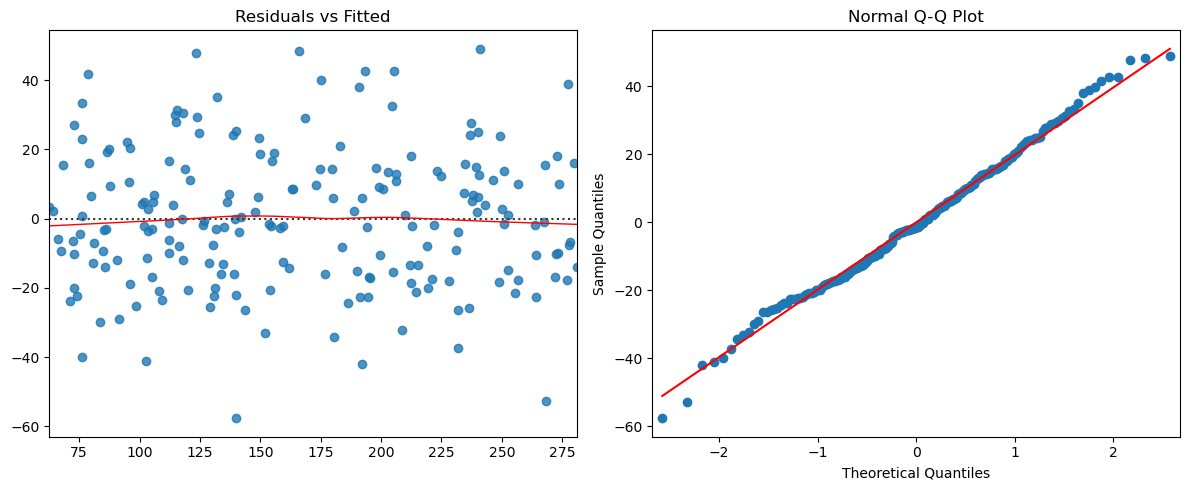

In [ ]:
# (b) plot residuals vs fitted values to check for patterns (describe what you see)
check_assumptions_regression(model)

# Based on diagnostic plots, your model looks very healthy. 

# Residuals vs Fitted (Left): 
# The residuals are spread randomly around the horizontal dashed line at zero. 
# The red trend line is nearly flat, which indicates that the relationship between predictors and outcome is linear. 
# There is no obvious "funnel" shape (heteroscedasticity) or "U" shape (missing non-linear terms).

# Normal Q-Q Plot (Right): 
# The majority of the data points fall directly on the red diagonal line. 
# This suggests that residuals are normally distributed, which is a key requirement for the p-values in regression table to be accurate.

In [ ]:
# (c) identify the 3 observations with the largest absolute residuals. 
# Are they outliers or just high-leverage points?

In [ ]:
# Create a series of absolute residuals
abs_resid = model.resid.abs().sort_values(ascending=False)

# Get the top 3 indices
top_3_indices = abs_resid.head(3).index
print(f"Indices with largest absolute residuals: {list(top_3_indices)}")

# Show the data for these specific rows
print(df1.loc[top_3_indices])

# These three points are outliers because their actual values are far from the predicted line (large vertical distance). 
# While indices 123 and 165 have high leverage due to their long article lengths, they follow the general trend and don't appear to be pulling the model's slope away from the other data points.

Indices with largest absolute residuals: [153, 123, 165]
     article_length  time_on_page  social_shares  publish_hour
153            1064     82.213615            116             8
123            2365    215.376642            102             9
165            2087    290.026574             37             5


In [33]:
# Calculate Cook's Distance

# Get influence measures
influence = model.get_influence()

# Extract Cook's Distance
cooks_d = influence.cooks_distance[0]

# View distances for your top 3 indices
top_3_indices = [153, 123, 165]
print("Cook's Distance for top 3 points:")
print(pd.Series(cooks_d, index=df1.index).loc[top_3_indices])

# Check against the rule-of-thumb threshold (4/n)
threshold = 4 / len(df1)
print(f"\nThreshold (4/n): {threshold:.4f}")


Cook's Distance for top 3 points:
153    0.026907
123    0.034321
165    0.035171
dtype: float64

Threshold (4/n): 0.0200


````
Below the Threshold: 
If these points are below the threshold (usually around 0.02 for 200 samples), they are "safe." 
They might be outliers, but the model isn't being "bullied" by them.

Above the Threshold: 
If any point is much higher than the others, it is a high-influence point. 
If we deleted that single row and re-ran our model, our coefficients (slopes) would change significantly.

Conclusion:
Since all three points are above the 0.02 threshold, they are technically influential observations. 
While they aren't "breaking" the model, their combination of large residuals and high leverage (especially for the longer articles like 123 and 165) is actively pulling the regression line toward them.
What to do next: Don't necessarily need to delete them, but it’s worth checking those specific rows in raw data for errors, like a user who accidentally left a tab open for a 2,000-word article but never actually read it!

In [ ]:
# Q5 Logistic regression (preview): 
# create a binary outcome: article_viral = 1 if social_shares > 75th percentile, else 0. 
# Run a logistic regression predicting viral status from article_length and publish_hour using statsmodels.formula.api.logit(). 
# Print the coefficients and interpret the odds ratios (exp of coefficients).

In [48]:
# create a binary outcome: article_viral = 1 if social_shares > 75th percentile, else 0. 

df1['article_viral'] = np.where(df1['social_shares'] >= df1['social_shares'].quantile(.75), 1, 0)
df1.sample(5)

,article_length,time_on_page,social_shares,publish_hour,article_viral
94,1727,217.076690,49,1,0
123,2365,215.376642,102,9,1
117,1152,149.763664,85,12,0
92,716,88.390677,49,8,0
72,634,73.049518,120,2,1


In [49]:
# Run a logistic regression predicting viral status from article_length and publish_hour using statsmodels.formula.api.logit()
model_conversion = smf.logit('article_viral ~ article_length + publish_hour', data=df1).fit()

Optimization terminated successfully.
         Current function value: 0.550269
         Iterations 5


In [51]:
# Print the coefficients and interpret the odds ratios (exp of coefficients).

print(model_conversion.summary())

odds_df = pd.DataFrame({
    'Odds Ratio' : np.exp(model_conversion.params).round(3),
    'CI Lower'   : np.exp(model_conversion.conf_int()[0]).round(3),
    'CI Upper'   : np.exp(model_conversion.conf_int()[1]).round(3),
    'p-value'    : model_conversion.pvalues.round(4)
})
display(odds_df)


                           Logit Regression Results                           
Dep. Variable:          article_viral   No. Observations:                  200
Model:                          Logit   Df Residuals:                      197
Method:                           MLE   Df Model:                            2
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.03081
Time:                        23:01:14   Log-Likelihood:                -110.05
converged:                       True   LL-Null:                       -113.55
Covariance Type:            nonrobust   LLR p-value:                   0.03024
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.2153      0.506     -4.379      0.000      -3.207      -1.224
article_length     0.0006      0.000      2.441      0.015       0.000       0.001
publish_hour       0.0228      0.024

,Odds Ratio,CI Lower,CI Upper,p-value
Intercept,0.109,0.040,0.294,0.0000
article_length,1.001,1.000,1.001,0.0147
publish_hour,1.023,0.975,1.073,0.3526


```
The Breakdown:

    Article Length (Significant): 
    With a p-value of 0.015, length is a significant predictor. 
    The positive coefficient (0.0006) means that as an article gets longer, the probability of it going viral increases.
    An extra 1,000 words increases the odds of virality by about 82% (e^0.6 = 1.82).

    Publish Hour (Not Significant): 
    The p-value of 0.353 is well above 0.05. 
    This means the time an article is posted has no reliable impact on whether it hits that top-25% "viral" threshold.

    Pseudo R-squared (0.0308): 
    This is very low. 
    It tells us that length and hour only explain about 3% of what makes an article go viral. 
    In the real world, "virality" is usually driven by factors your model isn't seeing, like topic, headline quality, or who shared it.
    
    LLR p-value (0.0302): 
    Since this is below 0.05, model is technically better than just guessing at random, but only barely.

The Verdict: If we want more viral articles, write longer ones, but don't expect a massive change just based on these two factors.